# Store CTD Plume Ensemble 

- loads in Landsat plume surface temperature timeseries
- Finds close in time and space CTD profiles (OMG and other literature)
- Runs plume model in ensemble for matching profiles


In [12]:
import os
import sys
import re
import glob
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import logging
from math import radians, sin, cos, sqrt, atan2
from datetime import datetime, timedelta
from scipy.stats.qmc import LatinHypercube
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

warnings.filterwarnings('ignore')
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

sys.path.insert(0, os.getcwd())   # plume_modelling/
from run_PLUME import run_plume

plt.rcParams.update({
    'font.size': 7,
    'font.family': 'sans-serif',
    'font.sans-serif': 'Helvetica',
})
print('Imports OK')

Imports OK


In [13]:
import yaml
from pathlib import Path

# Load paths from config.yaml (two levels up from scripts/plume_modelling/)
with open(Path('../../config.yaml')) as _f:
    cfg = yaml.safe_load(_f)

root_dir = Path('../../')
CSV_DIR = root_dir / cfg['paths']['landsat_plume_sst_dir']


FIGURES_DIR = root_dir / cfg['output']['figures_dir']
FIGURES_DIR.mkdir(exist_ok=True)

MATCHES_CACHE = root_dir / 'data' / 'STORE_CTD_landsat_matches_cache.csv'

## 1. Parameters

In [14]:
N_ENSEMBLE     = 100
GL_DEPTH_MIN   = 400.0   # m
GL_DEPTH_MAX   = 650.0   # m
MAX_TIME_DIFF  = 30      # days -- CTD must be within this many days of Landsat SST (+/-)
MAX_DIST_KM    = 10.0    # km   -- CTD must be within this distance of Store front
DEPTH_SIZE     = 1000    # matches num_intervals in run_PLUME.py

STORE_LAT = 70.38        # approximate Store glacier front
STORE_LON = -50.60

# run_PLUME uses a 2-D (line) plume: Q0 is volume flux per unit width (m2/s).
# Total Mankoff discharge Q_sg (m3/s) -> Q0 (m2/s) = Q_sg / PLUME_LINE_WIDTH_M
PLUME_LINE_WIDTH_M = 250   # assumed subglacial meltwater channel width at GL (m)

# Sensor-specific corrected RMSE from VALIDATION_STATISTICS.csv.
# L4 borrows L5 (same optical design; no L4 validation data).
_VALIDATION_CSV = Path(
    r'P:\Arctic_landsat_SST_cleanrepo\data\algorithm_params\VALIDATION_STATISTICS.csv'
)
_vstats = pd.read_csv(str(_VALIDATION_CSV), index_col='Sensor')
SENSOR_RMSE = {s: float(_vstats.loc[s, 'cor_RMSE']) for s in _vstats.index}
SENSOR_RMSE['L4'] = SENSOR_RMSE.get('L5', 0.608)


def get_q0_range(date):
    d = pd.Timestamp(date).normalize()
    Q_sg = float(mankoff_discharge.reindex([d], method='nearest').iloc[0])
    Q0_center = Q_sg / PLUME_LINE_WIDTH_M
    return [round(Q0_center * 0.6, 4), round(Q0_center * 1.6, 4)]


def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat = radians(lat2 - lat1); dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))


print('Parameters set.  SENSOR_RMSE:', SENSOR_RMSE)

Parameters set.  SENSOR_RMSE: {'L5': 0.6077062971383003, 'L7': 0.6121154236356691, 'L8': 0.5558139813893994, 'L9': 0.5099773616414667, 'L4': 0.6077062971383003}


## 2. Load Landsat SST time series
Same as `get_STORE_CTD_comparisons.ipynb` Ã¢â‚¬â€ stored as `glacier_data`.

In [15]:
import geopandas as gpd
import json as _json
from shapely.geometry import Polygon as _ShapelyPolygon

# --- Shapefile and bathymetry for grounding-line depth filtering ---
ICEFRONT_SHP = root_dir / cfg['paths']['store_icefront_shp']
BATHY_CSV    = root_dir / cfg['paths']['store_bathymetry_csv']

shp_icefront = gpd.read_file(str(ICEFRONT_SHP))
if shp_icefront.crs is None:
    shp_icefront = shp_icefront.set_crs('EPSG:4326')
if shp_icefront.crs.to_epsg() != 3413:
    shp_icefront = shp_icefront.to_crs(epsg=3413)
icefront_line = shp_icefront.geometry.iloc[0]

gl_bathy = pd.read_csv(str(BATHY_CSV)).sort_values('distance').reset_index(drop=True)
gl_bathy['distance'] = gl_bathy['distance'] * 1000  # km -> m

def _extract_centroid(geo_string):
    """Return (lat, lon) centroid of a GeoJSON Polygon/Point string."""
    try:
        geo = _json.loads(str(geo_string))
        if geo['type'] == 'Polygon':
            poly = _ShapelyPolygon(geo['coordinates'][0])
            c = poly.centroid
            return c.y, c.x
        elif geo['type'] == 'Point':
            return geo['coordinates'][1], geo['coordinates'][0]
    except Exception:
        pass
    return np.nan, np.nan

def _nearest_gl_depth(lat, lon):
    """Map WGS84 (lat, lon) to grounding-line depth (m, negative) via nearest
    point on the Store ice-front shapefile."""
    pt = gpd.GeoSeries(gpd.points_from_xy([lon], [lat]),
                       crs='EPSG:4326').to_crs(3413).iloc[0]
    d  = icefront_line.project(icefront_line.interpolate(icefront_line.project(pt)))
    idx = np.abs(gl_bathy['distance'] - d).argmin()
    return float(gl_bathy.iloc[idx]['depth'])


def extract_date(fname):
    m = re.search(r'\d{4}-\d{2}-\d{2}', fname)
    return pd.to_datetime(m.group(0)) if m else None


# --- Load CSVs, map to GL depth, filter to deep-GL plumes only ---
GL_DEPTH_THRESHOLD = -380   # keep only observations where GL depth < -380 m

csv_files = glob.glob(f'{CSV_DIR}/*.csv')
sst_records = []
n_shallow = 0
for f in csv_files:
    date = extract_date(f)
    if date is None:
        continue
    df_csv = pd.read_csv(f)
    sst = (df_csv['sst_masked_median'].values[0]
           if 'sst_masked_median' in df_csv.columns
           else df_csv['SST_median'].values[0])
    std = (df_csv['sst_masked_stdDev'].values[0]
           if 'sst_masked_stdDev' in df_csv.columns
           else df_csv['SST_stdDev'].values[0])

    # Map polygon centroid to GL depth
    gl_depth = np.nan
    if '.geo' in df_csv.columns:
        lat, lon = _extract_centroid(df_csv['.geo'].values[0])
        if not (np.isnan(lat) or np.isnan(lon)):
            try:
                gl_depth = _nearest_gl_depth(lat, lon)
            except Exception as e:
                pass

    if np.isnan(gl_depth) or gl_depth >= GL_DEPTH_THRESHOLD:
        n_shallow += 1
        continue

    # Read MAD and sensor for reviewer-required quadrature uncertainty
    _mad = float(df_csv['sst_mad_C'].values[0]) if 'sst_mad_C' in df_csv.columns else np.nan
    _sensor_map = {
        'LANDSAT_4': 'L4', 'L4': 'L4', 'LANDSAT_5': 'L5', 'L5': 'L5',
        'LANDSAT_7': 'L7', 'L7': 'L7', 'LANDSAT_8': 'L8', 'L8': 'L8',
        'LANDSAT_9': 'L9', 'L9': 'L9',
    }
    _sensor_raw = str(df_csv['sensor'].values[0]) if 'sensor' in df_csv.columns else ''
    _sensor_key = _sensor_map.get(_sensor_raw, 'L7')  # L7 fallback (highest RMSE)
    sst_records.append({
        'date': date, 'SST_median': sst, 'SST_stdDev': std,
        'sst_mad_C': _mad, 'sensor_key': _sensor_key, 'gl_depth': gl_depth,
    })

# Named glacier_data to match get_STORE_CTD_comparisons.ipynb
glacier_data = pd.DataFrame(sst_records).sort_values('date').reset_index(drop=True)
print(f'Loaded {len(glacier_data)} Landsat SST observations with GL depth < {abs(GL_DEPTH_THRESHOLD)} m')
print(f'Excluded {n_shallow} observations with GL depth >= {abs(GL_DEPTH_THRESHOLD)} m (shallow grounding line)')
glacier_data.head()


Loaded 83 Landsat SST observations with GL depth < 380 m
Excluded 10 observations with GL depth >= 380 m (shallow grounding line)


,date,SST_median,SST_stdDev,sst_mad_C,sensor_key,gl_depth
0,1985-06-22,1.641492,0.253708,0.0,L5,-522.524472
1,1985-07-01,1.641545,0.214766,0.0,L5,-467.682227
2,1985-07-03,1.642116,0.280729,0.0,L5,-467.682227
3,1987-06-30,1.085934,0.090431,0.0,L5,-467.682227
4,1987-08-08,2.198578,0.265784,0.0,L5,-542.546261


## 3. Load OMG AXCTD profiles

## 3a. Map verify CTD locations are near the Store ice front

In [16]:
OMG_DIR = root_dir / cfg['paths']['omg_ctd_dir']

omg_files = [f for f in glob.glob(f'{OMG_DIR}/*.nc')
             if 'shelf' not in os.path.basename(f).lower()]
print(f'Found {len(omg_files)} OMG (non-shelf) files')

_cache_df = pd.read_csv(str(MATCHES_CACHE)) if MATCHES_CACHE.exists() else None
if _cache_df is not None:
    _omg_in_cache = set(
        _cache_df.loc[~_cache_df['ctd_file'].str.startswith('STORE_Aug2010'), 'ctd_file'])
    omg_files = [f for f in omg_files if os.path.basename(f) in _omg_in_cache]
    print(f'Cache found — loading {len(omg_files)} matched OMG file(s)')

ctd_profiles = []
for f in sorted(omg_files):
    ds  = xr.open_dataset(f, decode_timedelta=False)
    dep = ds['depth'].values.squeeze()
    tem = ds['temperature'].values.squeeze()
    sal = ds['salinity'].values.squeeze()
    dat = pd.Timestamp(ds['time'].values.flat[0])
    lat = float(ds['lat'].values.flat[0])
    lon = float(ds['lon'].values.flat[0])

    if pd.isnull(dat):
        print(f'  {os.path.basename(f)}  -- NaT timestamp, skipping')
        continue

    dist_km = haversine_km(lat, lon, STORE_LAT, STORE_LON)
    if dist_km > MAX_DIST_KM:
        continue

    valid = ~(np.isnan(dep) | np.isnan(tem) | np.isnan(sal))
    dep, tem, sal = dep[valid], tem[valid], sal[valid]
    if len(dep) == 0:
        print(f'  {os.path.basename(f)}  -- all NaN after filter, skipping')
        continue
    s = np.argsort(dep)
    dep, tem, sal = dep[s], tem[s], sal[s]

    ctd_profiles.append({
        'date': dat, 'depth': dep, 'temp': tem, 'sal': sal,
        'lat': lat, 'lon': lon, 'dist_km': dist_km,
        'file': os.path.basename(f),
    })
    print(f'  {dat.date()}  max={dep.max():.0f}m  dist={dist_km:.1f}km')

print(f'\nKept {len(ctd_profiles)} profiles within {MAX_DIST_KM:.0f} km of Store front.')

Found 2158 OMG (non-shelf) files
Cache found — loading 4 matched OMG file(s)
  2016-09-15  max=727m  dist=7.5km
  2019-08-29  max=521m  dist=1.0km
  2020-08-25  max=717m  dist=3.8km
  2021-08-12  max=723m  dist=4.0km

Kept 4 profiles within 10 km of Store front.


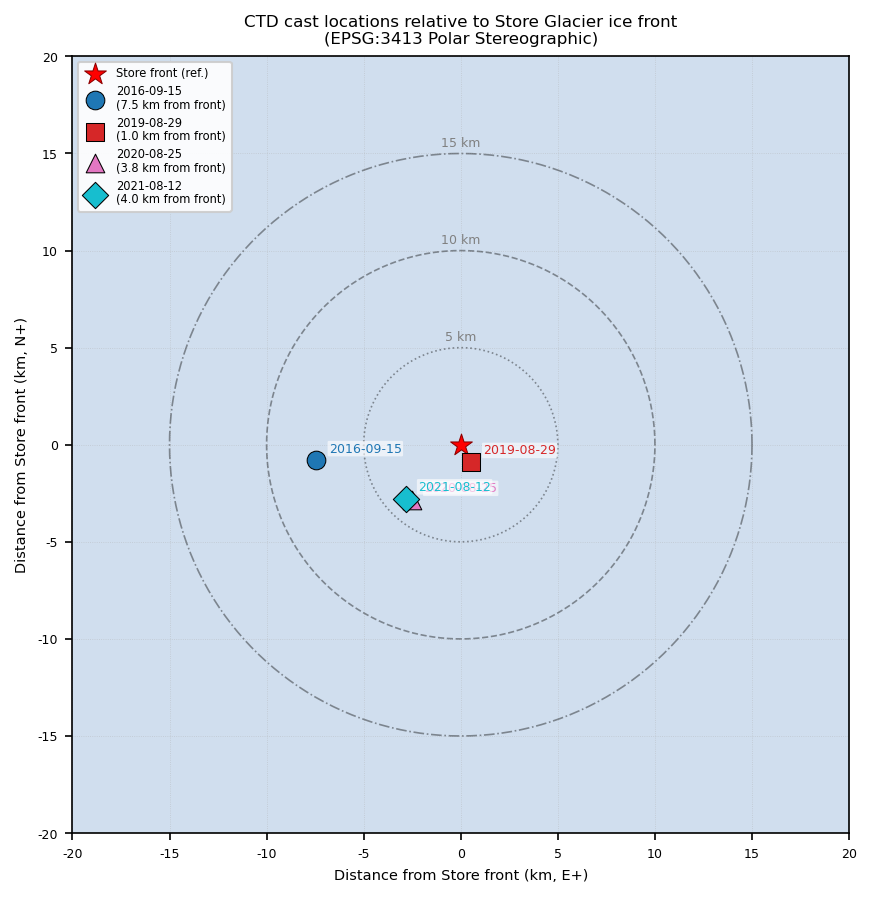

Saved: ..\..\figures\CTD_location_map.png

Date               Lat        Lon    Dist to Store (km)   Max depth (m)
----------------------------------------------------------------------
2016-09-15     70.3661   -50.7954                  7.46             727
2019-08-29     70.3724   -50.5840                  1.03             521
2020-08-25     70.3523   -50.6596                  3.80             717
2021-08-12     70.3527   -50.6681                  3.96             723


In [17]:
import geopandas as gpd
import pyproj
from matplotlib.patches import Circle
from matplotlib.lines import Line2D

SHP_FJORD = '../../data/shapefiles/fjord_boundary.shp'   # EPSG:3413 polygon

# Coordinate transformer  (WGS84 EPSG:3413 Polar Stereographic North) 
transformer = pyproj.Transformer.from_crs('EPSG:4326', 'EPSG:3413', always_xy=True)

def to_3413(lon, lat):
    x, y = transformer.transform(lon, lat)
    return x, y

# Store glacier front reference
store_x, store_y = to_3413(STORE_LON, STORE_LAT)

# Project CTD locations 
for ctd in ctd_profiles:
    ctd['x_3413'], ctd['y_3413'] = to_3413(ctd['lon'], ctd['lat'])

# Load fjord boundary shapefile 
try:
    fjord = gpd.read_file(SHP_FJORD)   # already in EPSG:3413
    has_fjord = True
except Exception as e:
    print(f'Could not load fjord shapefile: {e}')
    has_fjord = False

# Figure 
fig, ax = plt.subplots(figsize=(6, 6), dpi=150)

# Fjord boundary (ocean = blue, land = grey from context)
if has_fjord:
    fjord.plot(ax=ax, facecolor='#c8d9ec', edgecolor='#4a7ab5',
               linewidth=0.8, alpha=0.85, zorder=1, label='Fjord boundary')

# Distance rings around Store front (5, 10, 15 km)
angles  = np.linspace(0, 2 * np.pi, 361)
for r_km, ls, lw in [(5, ':', 0.8), (10, '--', 0.8), (15, '-.', 0.8)]:
    r_m = r_km * 1000
    cx  = store_x + r_m * np.cos(angles)
    cy  = store_y + r_m * np.sin(angles)
    ax.plot(cx, cy, color='k', linestyle=ls, linewidth=lw, alpha=0.4, zorder=2)
    ax.text(store_x, store_y + r_m + 200, f'{r_km} km',
            ha='center', va='bottom', fontsize=6, color='grey')

# Store glacier front reference
ax.scatter(store_x, store_y, s=120, color='red', marker='*',
           zorder=6, label='Store front (ref.)', edgecolors='darkred', linewidths=0.5)

# CTD locations one colour per cast
cmap    = plt.cm.tab10
markers = ['o', 's', '^', 'D', 'v', 'p', 'h', '*']
for i, ctd in enumerate(ctd_profiles):
    color  = cmap(i / max(len(ctd_profiles) - 1, 1))
    marker = markers[i % len(markers)]
    label  = (f"{ctd['date'].strftime('%Y-%m-%d')}\n"
              f"({ctd['dist_km']:.1f} km from front)")
    ax.scatter(ctd['x_3413'], ctd['y_3413'],
               s=80, color=color, marker=marker, edgecolors='k',
               linewidths=0.5, zorder=7, label=label)
    ax.annotate(ctd['date'].strftime('%Y-%m-%d'),
                xy=(ctd['x_3413'], ctd['y_3413']),
                xytext=(6, 4), textcoords='offset points',
                fontsize=6, color=color,
                bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.6, lw=0))

#Axes limits: centre on Store front, Ã‚Â±20 km 
margin = 20_000   # m
ax.set_xlim(store_x - margin, store_x + margin)
ax.set_ylim(store_y - margin, store_y + margin)

#Grid in km relative to Store front 
tick_m = np.arange(-20_000, 21_000, 5_000)
ax.set_xticks(store_x + tick_m)
ax.set_xticklabels([f'{int(t/1000)}' for t in tick_m], fontsize=6)
ax.set_yticks(store_y + tick_m)
ax.set_yticklabels([f'{int(t/1000)}' for t in tick_m], fontsize=6)
ax.set_xlabel('Distance from Store front (km, E+)', fontsize=7)
ax.set_ylabel('Distance from Store front (km, N+)', fontsize=7)

ax.set_aspect('equal')
ax.grid(True, linestyle=':', linewidth=0.4, alpha=0.5)
ax.set_title('CTD cast locations relative to Store Glacier ice front\n'
             '(EPSG:3413 Polar Stereographic)', fontsize=8)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='upper left', fontsize=5.5,
          framealpha=0.9, markerscale=1.0, borderpad=0.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'CTD_location_map.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR / 'CTD_location_map.png'}")

print(f'\n{"Date":<12}  {"Lat":>8}  {"Lon":>9}  {"Dist to Store (km)":>20}  {"Max depth (m)":>14}')
print('-' * 70)
for ctd in ctd_profiles:
    print(f"{ctd['date'].strftime('%Y-%m-%d'):<12}  "
          f"{ctd['lat']:8.4f}  {ctd['lon']:9.4f}  "
          f"{ctd['dist_km']:20.2f}  {ctd['depth'].max():14.0f}")

## 3b. Rignot et al. 2010 Store CTD profiles

In [18]:
RIGNOT_CTD_FILE = root_dir / cfg['paths']['rignot_ctd_file']
_ds_rig = xr.open_dataset(str(RIGNOT_CTD_FILE), decode_timedelta=False)

_rig_in_cache = (
    set(_cache_df.loc[_cache_df['ctd_file'].str.startswith('STORE_Aug2010'), 'ctd_file'])
    if _cache_df is not None else None
)

rignot_profiles = []
for _p in range(int(_ds_rig.dims['nprofiles'])):
    _file_id = f'STORE_Aug2010.nc:p{_p+1}'
    if _rig_in_cache is not None and _file_id not in _rig_in_cache:
        continue

    _ts  = float(_ds_rig['timestamp'].values[_p])
    _lat = float(_ds_rig['latitude'].values[_p])
    _lon = -float(_ds_rig['longitude'].values[_p])
    _dep = _ds_rig['depth'].values[:, _p]
    _tem = _ds_rig['temperature'].values[:, _p]
    _sal = _ds_rig['salinity'].values[:, _p]

    try:
        _dat = pd.Timestamp.fromordinal(int(_ts))
    except Exception:
        continue

    _dist = haversine_km(_lat, _lon, STORE_LAT, STORE_LON)
    if _dist > MAX_DIST_KM:
        continue

    _valid = ~(np.isnan(_dep) | np.isnan(_tem) | np.isnan(_sal)) & (_dep >= 0)
    _dep, _tem, _sal = _dep[_valid], _tem[_valid], _sal[_valid]
    if len(_dep) == 0:
        continue
    _s = np.argsort(_dep)
    _dep, _tem, _sal = _dep[_s], _tem[_s], _sal[_s]

    rignot_profiles.append({
        'date':    _dat,
        'depth':   _dep,
        'temp':    _tem,
        'sal':     _sal,
        'lat':     _lat,
        'lon':     _lon,
        'dist_km': _dist,
        'file':    _file_id,
    })
    print(f'  Rignot p{_p+1}: {_dat.date()}  max={_dep.max():.0f}m  dist={_dist:.1f}km')

print(f'\nKept {len(rignot_profiles)} Rignot profiles within {MAX_DIST_KM:.0f} km of Store front.')

all_ctd_profiles = ctd_profiles + rignot_profiles
print(f'Total CTD profiles available for matching: {len(all_ctd_profiles)}')


Kept 0 Rignot profiles within 10 km of Store front.
Total CTD profiles available for matching: 4


## 3c. Mankoff subglacial discharge (RACMO) for Store Gletscher

In [19]:
_MANKOFF_DIR = root_dir / cfg['paths']['mankoff_runoff_dir']
_ds_mank = xr.open_dataset(str(_MANKOFF_DIR / 'RACMO.nc'))

_basins    = _ds_mank['M2019_basin'].values
_coast_lat = _ds_mank['coast_lat'].values
_coast_lon = _ds_mank['coast_lon'].values

# All store glacier stations whose coastal exit is within MAX_DIST_KM of the front
_candidates = [
    i for i in range(len(_ds_mank['station']))
    if 'STORE_GLETSCHER' in str(_basins[i])
    and haversine_km(_coast_lat[i], _coast_lon[i], STORE_LAT, STORE_LON) < MAX_DIST_KM
]

# Use the single dominant outlet
_main_idx = max(_candidates,
    key=lambda i: float(_ds_mank['discharge'].isel(station=i).mean().values))

mankoff_discharge = _ds_mank['discharge'].isel(station=_main_idx).to_series()

_sid  = int(_ds_mank['station'].values[_main_idx])
_dist = haversine_km(_coast_lat[_main_idx], _coast_lon[_main_idx], STORE_LAT, STORE_LON)
_smn  = mankoff_discharge[mankoff_discharge.index.month.isin([7,8,9])].mean()
print(f'Main Store outlet: station {_sid}, {_dist:.2f} km from front')
print(f'Summer mean discharge: {_smn:.1f} m3/s')
print(f'Date range: {mankoff_discharge.index[0].date()} to {mankoff_discharge.index[-1].date()}')

Main Store outlet: station 57996, 1.24 km from front
Summer mean discharge: 177.3 m3/s
Date range: 1958-01-01 to 2022-12-31


## 4. Match CTDs to Landsat SST observations

In [20]:
_loaded_from_cache = False

if MATCHES_CACHE.exists():
    _df = pd.read_csv(MATCHES_CACHE)
    matches = []
    for _, row in _df.iterrows():
        ctd = next(
            (c for c in all_ctd_profiles
             if c['file'] == row['ctd_file']
             and c['date'].normalize() == pd.Timestamp(row['ctd_date'])),
            None)
        if ctd is None:
            print(f"  Warning: {row['ctd_file']} ({row['ctd_date']}) not found in loaded profiles")
            continue
        ls_row = glacier_data[glacier_data['date'].dt.normalize() == pd.Timestamp(row['ls_date'])]
        if ls_row.empty:
            print(f"  Warning: Landsat {row['ls_date']} not found in glacier_data")
            continue
        matches.append({'ctd': ctd, 'ls': ls_row.iloc[0], 'time_diff': int(row['time_diff_d'])})
    _loaded_from_cache = True
    print(f'Loaded {len(matches)} matches from {MATCHES_CACHE.name}')

else:
    matches = []
    for ctd in all_ctd_profiles:
        candidates = []
        for _, ls_row in glacier_data.iterrows():
            dt = (ls_row['date'].normalize() - ctd['date'].normalize()).days
            if abs(dt) <= MAX_TIME_DIFF:
                candidates.append((abs(dt), dt, ls_row))
        if not candidates:
            print(f'  No match for CTD {ctd["date"].date()} within {MAX_TIME_DIFF}d '
                  f'(after GL-depth filter)')
            continue

        print(f'\nCTD {ctd["date"].date()} ({ctd["file"]}) '
              f'--- candidates within +/-{MAX_TIME_DIFF} days:')
        for abs_dt, dt_c, row in sorted(candidates, key=lambda x: x[0]):
            direction = 'Landsat before CTD' if dt_c < 0 else 'Landsat after CTD'
            print(f'  SST {row["date"].date()}  dt={dt_c:+d}d  ({direction})  '
                  f'GL={row["gl_depth"]:.0f}m')

        candidates.sort(key=lambda x: x[0])
        _, dt, ls_row = candidates[0]
        matches.append({'ctd': ctd, 'ls': ls_row, 'time_diff': dt})

    print(f'\nFinal: {len(matches)} CTD-Landsat matches '
          f'(|dt| <= {MAX_TIME_DIFF}d, dist <= {MAX_DIST_KM}km, GL < {abs(GL_DEPTH_THRESHOLD)}m):')
    for i, m in enumerate(matches):
        dt = m['time_diff']
        direction = 'Landsat before CTD' if dt < 0 else 'Landsat after CTD'
        print(f'  [{i}] CTD {m["ctd"]["date"].date()} ({m["ctd"]["file"]}) + '
              f'SST {m["ls"]["date"].date()}  dt={dt:+d}d  ({direction})  '
              f'dist={m["ctd"]["dist_km"]:.1f}km  GL={m["ls"]["gl_depth"]:.0f}m')

Loaded 4 matches from STORE_CTD_landsat_matches_cache.csv


In [21]:
if not _loaded_from_cache:
    pd.DataFrame([{
        'ctd_file':    m['ctd']['file'],
        'ctd_date':    m['ctd']['date'].strftime('%Y-%m-%d'),
        'ctd_lat':     round(m['ctd']['lat'], 4),
        'ctd_lon':     round(m['ctd']['lon'], 4),
        'ctd_dist_km': round(m['ctd']['dist_km'], 2),
        'ls_date':     m['ls']['date'].strftime('%Y-%m-%d'),
        'ls_sst':      round(m['ls']['SST_median'], 3),
        'ls_gl_depth': round(m['ls']['gl_depth'], 1),
        'time_diff_d': m['time_diff'],
    } for m in matches]).to_csv(str(MATCHES_CACHE), index=False)
    print(f'Saved {len(matches)} matches to {MATCHES_CACHE.name}')

## 5. Run plume ensemble for each match (in-memory)

In [ ]:
SOL_VARS = ['z','b','u','T','S','N','Sb','Tb','mdot','rho','Ta','Sa','Na','rhoa']

def pad_to(arr, n=DEPTH_SIZE):
    out = np.full(n, np.nan)
    k   = min(len(arr), n)
    out[:k] = arr[:k]
    return out


def prepare_profile(depth_pos, temp, sal):
    d_grid = np.arange(0, int(depth_pos.max()) + 1, 1.0)
    t_grid = np.interp(d_grid, depth_pos, temp)
    s_grid = np.interp(d_grid, depth_pos, sal)
    if d_grid[-1] < GL_DEPTH_MAX:
        extra  = np.arange(d_grid[-1] + 1, GL_DEPTH_MAX + 1, 1.0)
        base_d = np.append(d_grid, extra)
        base_t = np.append(t_grid, np.full(len(extra), t_grid[-1]))
        base_s = np.append(s_grid, np.full(len(extra), s_grid[-1]))
    else:
        mask   = d_grid <= GL_DEPTH_MAX
        base_d = d_grid[mask]; base_t = t_grid[mask]; base_s = s_grid[mask]
    return base_d, base_t, base_s


def _run_members(base_d, base_t, base_s, q0_lo, q0_hi, seed):
    sampler    = LatinHypercube(d=3, seed=seed)
    samps      = sampler.random(n=N_ENSEMBLE)
    gl_vals    = GL_DEPTH_MIN + samps[:, 0] * (GL_DEPTH_MAX - GL_DEPTH_MIN)
    Q0_vals    = q0_lo        + samps[:, 1] * (q0_hi - q0_lo)
    alpha_vals = 0.05         + samps[:, 2] * 0.10
    arr        = {v: np.full((N_ENSEMBLE, DEPTH_SIZE), np.nan) for v in SOL_VARS}
    alpha_arr  = np.full((N_ENSEMBLE, DEPTH_SIZE), np.nan)
    Q0_arr     = np.full((N_ENSEMBLE, DEPTH_SIZE), np.nan)
    gl_arr     = np.full((N_ENSEMBLE, DEPTH_SIZE), np.nan)
    n_ok = 0
    for j, (gl_d, Q0, alpha) in enumerate(zip(gl_vals, Q0_vals, alpha_vals)):
        mask_run = base_d <= gl_d
        if mask_run.sum() < 5:
            continue
        zi = -base_d[mask_run]; ti = base_t[mask_run]; si = base_s[mask_run]
        if abs(zi[-1]) < gl_d - 0.5:
            zi = np.append(zi, -gl_d); ti = np.append(ti, ti[-1]); si = np.append(si, si[-1])
        try:
            sol = run_plume(zi, np.zeros_like(zi), ti, si, np.ones_like(zi),
                            Q0, alpha, stop_on_zero_velocity=True)
        except Exception:
            continue
        if not sol or len(sol.get('T', [])) == 0:
            continue
        for v in SOL_VARS:
            arr[v][j] = pad_to(np.array(sol[v]))
        alpha_arr[j] = alpha
        Q0_arr[j]    = Q0
        gl_arr[j]    = gl_d
        n_ok += 1
    return arr, alpha_arr, Q0_arr, gl_arr, n_ok


def run_ensemble_to_dataset(match, seed=42):
    ctd  = match['ctd']
    ls   = match['ls']
    date = ctd['date']

    try:
        _d = pd.Timestamp(date).normalize()
        mankoff_q_sg = float(mankoff_discharge.reindex([_d], method='nearest').iloc[0])
    except Exception:
        mankoff_q_sg = float('nan')

    base_d, base_t, base_s = prepare_profile(ctd['depth'], ctd['temp'], ctd['sal'])
    q0_lo, q0_hi = get_q0_range(date)

    for _attempt in range(40):
        arr, alpha_arr, Q0_arr, gl_arr, n_ok = _run_members(
            base_d, base_t, base_s, q0_lo, q0_hi, seed)
        z_finals = np.array([
            arr['z'][j][~np.isnan(arr['z'][j])][-1]
            for j in range(N_ENSEMBLE)
            if np.any(~np.isnan(arr['z'][j]))
        ])
        if np.sum(z_finals > -5) >= 3:
            break
        q0_lo *= 1.1
        q0_hi *= 1.1

    _valid_j = [j for j in range(N_ENSEMBLE) if np.any(~np.isnan(arr['T'][j]))]
    T_finals = np.array([arr['T'][j][~np.isnan(arr['T'][j])][-1] for j in _valid_j])
    T_surf_med = np.nanmedian(T_finals) if len(T_finals) > 0 else float('nan')

    print(f'  CTD={date.date()}  SST={ls["date"].date()}  '
          f'Q_sg={mankoff_q_sg:.0f} m3/s  Q0=[{q0_lo:.3f},{q0_hi:.3f}] m2/s  '
          f'n_converged={n_ok}  '
          f'T_surf_med={T_surf_med:.2f}C')

    coords = {'ensemble_run': np.arange(N_ENSEMBLE), 'depth': np.arange(DEPTH_SIZE)}
    data_vars = {v: xr.DataArray(arr[v], dims=['ensemble_run','depth']) for v in SOL_VARS}
    data_vars['alpha']               = xr.DataArray(alpha_arr, dims=['ensemble_run','depth'])
    data_vars['Q0']                  = xr.DataArray(Q0_arr,    dims=['ensemble_run','depth'])
    data_vars['grounding_line_depth']= xr.DataArray(gl_arr,    dims=['ensemble_run','depth'])
    data_vars['mean_T']              = xr.DataArray(np.nanmean(arr['T'], axis=0), dims=['depth'])

    ds = xr.Dataset(data_vars, coords=coords)
    ds.attrs = {
        'sst_time':          ls['date'].strftime('%Y-%m-%d'),
        'ctd_time':          date.strftime('%Y-%m-%d'),
        'ctd_file':          ctd['file'],
        'time_diff':         int(match['time_diff']),
        'distance':          float(ctd['dist_km']),
        'landsat_sst_mean':  float(ls['SST_median']),
        'landsat_sst_error': float(
            np.sqrt(
                (float(ls['sst_mad_C']) if not np.isnan(float(ls['sst_mad_C'])) else float(ls['SST_stdDev']))**2
                + SENSOR_RMSE.get(str(ls['sensor_key']), 0.612)**2
            )
        ),
        'mankoff_q_sg':      round(mankoff_q_sg, 2),
        'q0_lo':             round(q0_lo, 4),
        'q0_hi':             round(q0_hi, 4),
    }
    return ds


print(f'Running ensemble (n={N_ENSEMBLE}) for {len(matches)} matches...')
ensemble_datasets = []
for i, m in enumerate(matches):
    ds = run_ensemble_to_dataset(m, seed=42 + i)
    ensemble_datasets.append(ds)
print(f'\nDone - {len(ensemble_datasets)} ensemble datasets in memory.')

# save to disk as one file in data\ctd_plume_simulations
OUTPUT_DIR = '../../data/ctd_plume_simulations'
output_file = OUTPUT_DIR + '/STORE_CTD_plume_ensembles.nc'
xr.concat(ensemble_datasets, dim='match').to_netcdf(str(output_file))
print(f'Saved ensemble results to {output_file}')

Running ensemble (n=100) for 4 matches...


  CTD=2016-09-15  SST=2016-08-30  Q_sg=16 m3/s  Q0=[0.189,0.503] m2/s  n_converged=100  T_surf_med=2.00C
  CTD=2019-08-29  SST=2019-08-09  Q_sg=20 m3/s  Q0=[0.217,0.580] m2/s  n_converged=100  T_surf_med=1.27C
  CTD=2020-08-25  SST=2020-08-20  Q_sg=89 m3/s  Q0=[0.213,0.567] m2/s  n_converged=100  T_surf_med=1.55C
  CTD=2021-08-12  SST=2021-08-05  Q_sg=234 m3/s  Q0=[0.562,1.499] m2/s  n_converged=100  T_surf_med=1.27C

Done - 4 ensemble datasets in memory.


KeyError: 'ctd_plume_simulations_dir'

In [26]:
OUTPUT_DIR = '../../data/ctd_plume_simulations'
output_file = OUTPUT_DIR + '/STORE_CTD_plume_ensembles.nc'
xr.concat(ensemble_datasets, dim='match').to_netcdf(str(output_file))
print(f'Saved ensemble results to {output_file}')

Saved ensemble results to ../../data/ctd_plume_simulations/STORE_CTD_plume_ensembles.nc


In [27]:
def plot_plume_ensemble(ensemble_dataset, ax1, ax2, xmin, xmax, label):
    # ---- Landsat SST from stored attrs ----
    landsat_sst_time   = pd.to_datetime(ensemble_dataset.attrs['sst_time'])
    landsat_sst_median = ensemble_dataset.attrs['landsat_sst_mean']
    sst_error          = ensemble_dataset.attrs['landsat_sst_error']

    # ---- Grey ensemble profiles ----
    for ens in ensemble_dataset['ensemble_run']:
        sel = ensemble_dataset.sel(ensemble_run=ens)
        ax1.plot(sel['T'].values, sel['z'].values,
                 color='grey', alpha=0.95, linewidth=0.2)

    # ---- Ensemble mean — same approach as original get_STORE_CTD_comparisons.ipynb ----
    # Average T and z at each depth index across all ensemble members (skipna to
    # exclude NaN-padded entries from runs that terminated before that index).
    ensemble_mean_T = ensemble_dataset['T'].mean(dim='ensemble_run', skipna=True)
    ensemble_mean_z = ensemble_dataset['z'].mean(dim='ensemble_run', skipna=True)
    valid_m = ~(np.isnan(ensemble_mean_T.values) | np.isnan(ensemble_mean_z.values))
    ax1.plot(ensemble_mean_T.values[valid_m], ensemble_mean_z.values[valid_m],
             color='k', linestyle='--', linewidth=1.2, label='Ensemble mean')

    # Surface T: last valid point on the mean profile
    if valid_m.any():
        surface_mean_T = float(ensemble_mean_T.values[valid_m][-1])
    else:
        surface_mean_T = np.nan
    print(f"  SST {landsat_sst_time.date()}  "
          f"Plume surface T (ensemble mean): {surface_mean_T:.2f}\u00b0C  "
          f"Landsat SST: {landsat_sst_median:.2f}\u00b0C")

    # ---- z = 0 reference ----
    ax1.hlines(0, xmin, xmax, color='k', linestyle='--', linewidth=0.5)

    # ---- Landsat SST at z = 0 ----
    ax1.errorbar(landsat_sst_median, 0, xerr=sst_error,
                 fmt='o', color='blue', zorder=5, ecolor='black', capsize=5)
    ax1.scatter(landsat_sst_median, 0, color='orange', s=60, zorder=6,
                edgecolors='k', label='Landsat SST median')

    ax1.set_xlim(xmin, xmax)

    # ---- CTD ambient temperature ----
    CTD_temp  = ensemble_dataset['Ta'].median(dim='ensemble_run')
    CTD_sal   = ensemble_dataset['Sa'].median(dim='ensemble_run')
    CTD_depth = ensemble_dataset['z'].median(dim='ensemble_run')

    CTD_temp  = CTD_temp[::-1]
    CTD_sal   = CTD_sal[::-1]
    CTD_depth = CTD_depth[::-1]

    valid_ctd = ~(np.isnan(CTD_depth.values) | np.isnan(CTD_temp.values))
    CTD_temp  = CTD_temp[valid_ctd]
    CTD_sal   = CTD_sal[valid_ctd]
    CTD_depth = CTD_depth[valid_ctd]

    last_temp = float(CTD_temp[-1])
    last_sal  = float(CTD_sal[-1])

    extended_depth = np.append(CTD_depth, -GL_DEPTH_MAX)
    extended_temp  = np.append(CTD_temp,  last_temp)
    extended_sal   = np.append(CTD_sal,   last_sal)

    ax1.plot(CTD_temp, CTD_depth, color='royalblue', alpha=0.9,
             linewidth=1.5, linestyle='-', label='CTD temp.')
    ax2.plot(CTD_sal,  CTD_depth, color='k', linewidth=1.2,
             linestyle='-', label='CTD salinity')

    ax1.plot(extended_temp[-2:], extended_depth[-2:],
             color='royalblue', alpha=0.9, linewidth=1.5, linestyle='dotted')
    ax2.plot(extended_sal[-2:], extended_depth[-2:],
             color='k', linewidth=1.2, linestyle=':')

    # ---- Salinity axis ----
    ax2.set_ylim(ax1.get_ylim())
    ax2.yaxis.tick_right()
    ax2.yaxis.set_label_position('right')
    ax2.set_ylabel('Depth (m)')
    s_vals = CTD_sal.values[~np.isnan(CTD_sal.values)]
    if len(s_vals) > 0:
        ax2.hlines(0, s_vals.min(), s_vals.max(),
                   color='k', linestyle='--', linewidth=0.5)

    # ---- Subplot label ----
    ax1.text(-0.15, 1.05, label, transform=ax1.transAxes,
             fontsize=10, va='top', ha='right')

    # ---- Title ----
    time_diff = ensemble_dataset.attrs['time_diff']
    distance  = ensemble_dataset.attrs['distance']
    ax1.set_title(f"{landsat_sst_time.strftime('%Y-%m-%d')}, "
                  f"t: {time_diff:+d}d, d: {distance:.2f} km",
                  fontsize=8, loc='left', y=0.97)


def create_subplot_figure(datasets, xmins, xmaxs, save_path=None):
    n = len(datasets)
    if n == 0:
        print('No datasets to plot.')
        return
    fig_width_mm  = 250 / 3 * n
    fig_height_mm = 60
    inch = 0.0393701
    fig  = plt.figure(figsize=(fig_width_mm * inch, fig_height_mm * inch), dpi=300)

    gs_main = GridSpec(1, n, figure=fig, wspace=0.2, hspace=0.2)
    subplot_labels = list('abcdefghijklmnopqrstuvwxyz')

    for i, (ds, xmin, xmax, lbl) in enumerate(zip(datasets, xmins, xmaxs, subplot_labels)):
        gs_sub = GridSpecFromSubplotSpec(
            1, 2, subplot_spec=gs_main[0, i],
            width_ratios=[4.5, 1], wspace=0.05)
        ax1 = fig.add_subplot(gs_sub[0, 0])
        ax2 = fig.add_subplot(gs_sub[0, 1])

        plot_plume_ensemble(ds, ax1, ax2, xmin, xmax, lbl)

        ax1.set_xlabel('Temperature (\u00b0C)')
        ax2.set_xlabel('Salinity (psu)')

        if i > 0:
            ax1.set_yticklabels([])
            ax2.set_yticklabels([])
            ax2.set_ylabel('')
        else:
            ax1.set_ylabel('Depth (m)')
            ax2.set_yticklabels([])
            ax2.set_ylabel('')

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.tight_layout()
    plt.show()


print('Plot functions defined.')


Plot functions defined.


## 7. Generate figure

Edit `selected_indices` to choose which CTDÃ¢â‚¬â€œLandsat pairs to plot
(the original `get_STORE_CTD_comparisons.ipynb` used indices 0, 1, 2).

`xmins` / `xmaxs` are auto-computed from the data; override below if needed.

Plotting 3 panels...
x-limits: [(0, np.float64(2.79)), (0, np.float64(2.17)), (0, np.float64(2.5))]
  SST 2016-08-30  Plume surface T (ensemble mean): 1.77°C  Landsat SST: 1.34°C
  SST 2019-08-09  Plume surface T (ensemble mean): 0.99°C  Landsat SST: 1.63°C
  SST 2020-08-20  Plume surface T (ensemble mean): 1.27°C  Landsat SST: 2.30°C
Saved: ..\..\figures\STORE_CTD_plume_ensemble_combined.png


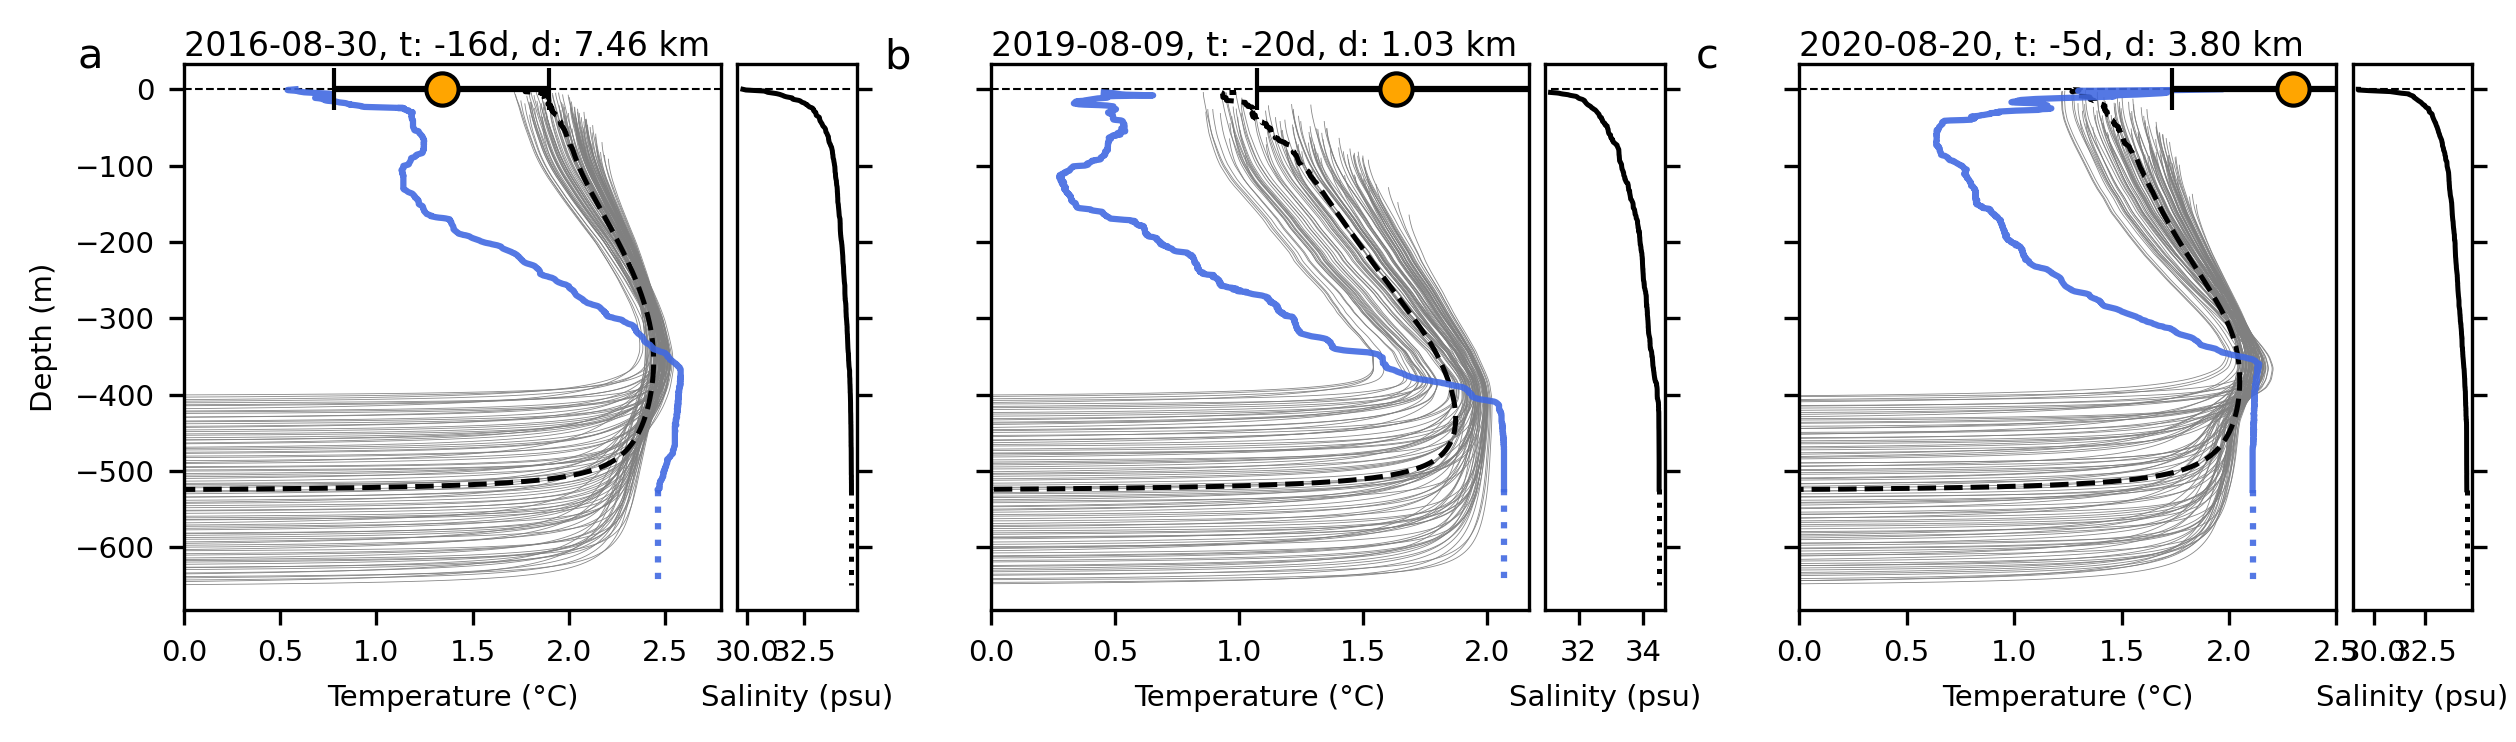

In [28]:
# ---- Select which matches to plot ----
selected_indices = list(range(min(len(ensemble_datasets), 3)))
# selected_indices = [0, 2, 3]   # uncomment to pick a subset

selected_ds = [ensemble_datasets[i] for i in selected_indices]

# Auto x-limits from each dataset
def auto_xlims(ds, pad=0.1):
    T_vals = ds['T'].values
    Ta_vals = ds['Ta'].values
    all_T = np.concatenate([T_vals[~np.isnan(T_vals)], Ta_vals[~np.isnan(Ta_vals)]])
    return round(max(all_T.min() - pad, -0.5), 1), round(all_T.max() + pad, 2)

xmins = [auto_xlims(ds)[0] for ds in selected_ds]
xmaxs = [auto_xlims(ds)[1] for ds in selected_ds]

# xmin should be 0 for all plots as this is the initial temp of the plume
xmins = [0] * len(selected_ds) # override to 0 for all plots
print('Plotting', len(selected_ds), 'panels...')
print('x-limits:', list(zip(xmins, xmaxs)))

create_subplot_figure(
    selected_ds, xmins, xmaxs,
    save_path=str(FIGURES_DIR / 'STORE_CTD_plume_ensemble_combined.png')
)